## 1. Project Introduction

The goal of this project is to build and evaluate a portfolio-level pairs trading strategy using historical S&P 500 stock prices. Pairs trading is a relative-value strategy that seeks to identify two stocks with a stable long-run relationship. When their relationship temporarily diverges, the strategy takes opposing positions and attempts to profit as the spread returns toward equilibrium.

Candidate pairs are first screened using sector membership and return correlation. For each pair, I estimate a hedge ratio using linear regression, construct the resulting spread, and test whether it is cointegrated and mean-reverting. Additional filters, including spread stationarity and estimated mean-reversion half-life, are used to remove unstable relationships.

The strategy is implemented through a quarterly walk-forward framework. At each rebalance date, pairs are re-estimated and evaluated using only historical data available at that time. Several z-score trading configurations are tested across sequential validation folds, and configurations with sufficiently consistent performance are combined into an ensemble. Graph-based matching is then used to select non-overlapping pairs, which are combined into a diversified portfolio using volatility- and validation-aware weights.

Trades are entered when a spread moves sufficiently far from its recent equilibrium and begins reverting. Positions are exited when the spread approaches its mean, reaches a stop-loss threshold, or exceeds its maximum holding period. Transaction costs are incorporated, and a portfolio-level volatility throttle reduces exposure during unusually volatile periods.

Performance is assessed at the portfolio level using cumulative return, annualized return, volatility, Sharpe ratio, maximum drawdown, active-day win rate, turnover, and transaction costs. The analysis focuses on whether statistically strong relationships remain profitable in subsequent walk-forward periods and whether portfolio construction and risk control improve the consistency of returns.

Because several alternative specifications were explored using the same historical sample, the final result should be interpreted as a development-period walk-forward backtest rather than a fully untouched out-of-sample estimate.


## 2. Import Libraries

I use yfinance to download stock prices, statsmodels for regression and cointegration tests, and pandas/numpy for data cleaning and backtesting.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
import seaborn as sns

## 3. Load Data

In this section, I download historical daily price data for all current S&P 500 stocks. I first scrape the list of S&P 500 tickers from Wikipedia, then use the `yfinance` package to download adjusted daily closing prices.

Using the full S&P 500 universe gives the project a much larger search space for finding potentially cointegrated stock pairs. However, because this creates many possible pairs, later sections will need to carefully control overfitting using in-sample and out-of-sample testing.

In [2]:
import sys
!{sys.executable} -m pip install --upgrade certifi

  Attempting uninstall: certifi
    Found existing installation: certifi 2026.4.22
    Uninstalling certifi-2026.4.22:
      Successfully uninstalled certifi-2026.4.22

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [604]:
import requests
import certifi
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, verify=certifi.where())
response.raise_for_status()

# Read the HTML table from the downloaded page
sp500_table = pd.read_html(StringIO(response.text))[0]

# Extract ticker symbols
tickers = sp500_table["Symbol"].tolist()

# Yahoo Finance uses "-" instead of "." in tickers like BRK.B
tickers = [ticker.replace(".", "-") for ticker in tickers]

print("Number of tickers:", len(tickers))
print(tickers[:10])
# Full data download:
# development period plus untouched 2025 holdout
download_start = "2018-01-01"
download_end_exclusive = "2026-01-01"

data = yf.download(
    tickers,
    start=download_start,
    end=download_end_exclusive,
    auto_adjust=True,
    group_by="column",
    threads=True,
    progress=True
)

# Extract closing prices
prices = data["Close"]

prices.head()
print("Number of trading days:", prices.shape[0])
print("Number of stocks:", prices.shape[1])

prices.to_csv("sp500_prices.csv")

Number of tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


[**********************46%                       ]  231 of 503 completed$FDXF: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1767243600")
[*********************100%***********************]  503 of 503 completed

1 Failed download:
['FDXF']: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1767243600")


Number of trading days: 2011
Number of stocks: 503


## 4. Clean Data

In this section, I clean the downloaded S&P 500 price data before doing cointegration testing. Some stocks may have missing prices because they were added to the S&P 500 later, changed tickers, or had incomplete Yahoo Finance data.

I remove stocks with too many missing values, then drop the remaining dates with missing observations. After cleaning, I convert prices into log prices because cointegration tests and spread construction are usually performed using log price series.

This cleaning step is important because the later cointegration and backtesting steps require aligned price histories across stocks.

In [605]:
# Check the original data shape
print("Original price data shape:", prices.shape)

# Count missing values for each stock
missing_counts = prices.isna().sum().sort_values(ascending=False)

# Show stocks with the most missing values
missing_counts.head(20)

Original price data shape: (2011, 503)


Ticker
FDXF    2011
Q       1965
SNDK    1789
GEV     1568
SOLV    1567
VLTO    1448
KVUE    1343
GEHC    1248
CEG     1019
HOOD     899
APP      826
COIN     825
EXE      782
ABNB     741
DASH     740
PLTR     691
OTIS     556
CARR     556
DDOG     431
CRWD     362
dtype: int64

In [606]:
missing_percent = (prices.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary.head(20)

,missing_count,missing_percent
Ticker,,
FDXF,2011,100.000000
Q,1965,97.712581
SNDK,1789,88.960716
GEV,1568,77.971159
SOLV,1567,77.921432
VLTO,1448,72.003978
KVUE,1343,66.782695
GEHC,1248,62.058677
CEG,1019,50.671308


In [607]:
# Keep stocks with at least 95% non-missing observations
min_non_missing = int(0.95 * len(prices))

prices_clean = prices.dropna(axis=1, thresh=min_non_missing)

print("Shape before removing incomplete stocks:", prices.shape)
print("Shape after removing incomplete stocks:", prices_clean.shape)

Shape before removing incomplete stocks: (2011, 503)
Shape after removing incomplete stocks: (2011, 476)


In [608]:
# Drop any remaining dates with missing values
prices_clean = prices_clean.dropna()

print("Final cleaned price data shape:", prices_clean.shape)

# Check that there are no missing values left
print("Total missing values after cleaning:", prices_clean.isna().sum().sum())

Final cleaned price data shape: (2010, 476)
Total missing values after cleaning: 0


In [609]:
# Remove any columns with non-positive prices, since log prices require positive values
positive_price_stocks = (prices_clean > 0).all(axis=0)

prices_clean = prices_clean.loc[:, positive_price_stocks]

print("Shape after removing non-positive price series:", prices_clean.shape)

Shape after removing non-positive price series: (2010, 476)


In [610]:
log_prices = np.log(prices_clean)

log_prices.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,4.151398,3.695534,4.230813,3.922094,3.331780,4.909401,5.180097,4.348862,3.440479,4.568597,...,3.234731,5.008497,3.615077,4.063636,4.117505,3.588230,4.246177,4.723719,4.641599,4.201914
2018-01-03,4.176524,3.695360,4.246341,3.924302,3.332685,4.914006,5.198718,4.361191,3.432717,4.579402,...,3.243474,4.997604,3.608361,4.083086,4.129624,3.619261,4.245319,4.730627,4.661267,4.206503
2018-01-04,4.168994,3.699994,4.240622,3.922604,3.336412,4.925777,5.210688,4.360097,3.449419,4.588909,...,3.235297,5.003004,3.600540,4.084469,4.136278,3.640214,4.255448,4.729185,4.680834,4.212449
2018-01-05,4.184856,3.711315,4.257880,3.925490,3.332459,4.933993,5.222192,4.364141,3.442722,4.588317,...,3.233881,5.009653,3.593511,4.083662,4.134403,3.716981,4.261259,4.739077,4.696290,4.223827
2018-01-08,4.187000,3.707594,4.241728,3.922604,3.332572,4.941952,5.220572,4.365885,3.440479,4.585269,...,3.240380,4.996249,3.600964,4.088148,4.138007,3.707701,4.262948,4.740980,4.706191,4.235752


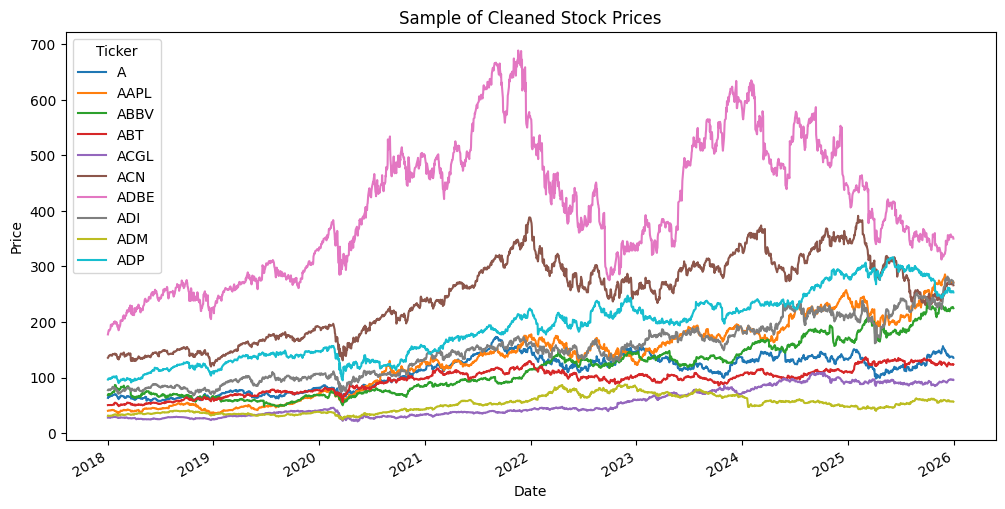

In [611]:
# Plot a few cleaned price series to check that the data looks reasonable
prices_clean.iloc[:, :10].plot(figsize=(12, 6), title="Sample of Cleaned Stock Prices")

plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [612]:
# ============================================================
# DEVELOPMENT / HOLDOUT SPLIT
# ============================================================

DEVELOPMENT_START = pd.Timestamp("2018-01-01")
HOLDOUT_START = pd.Timestamp("2025-01-01")
HOLDOUT_END_EXCLUSIVE = pd.Timestamp("2026-01-01")

development_prices = prices_clean.loc[
    (prices_clean.index >= DEVELOPMENT_START)
    & (prices_clean.index < HOLDOUT_START)
].copy()

holdout_prices = prices_clean.loc[
    (prices_clean.index >= HOLDOUT_START)
    & (prices_clean.index < HOLDOUT_END_EXCLUSIVE)
].copy()

print("Development period:")
print(
    development_prices.index.min(),
    "to",
    development_prices.index.max()
)
print("Development shape:", development_prices.shape)

print("\nHoldout period:")
print(
    holdout_prices.index.min(),
    "to",
    holdout_prices.index.max()
)
print("Holdout shape:", holdout_prices.shape)

Development period:
2018-01-02 00:00:00 to 2024-12-31 00:00:00
Development shape: (1761, 476)

Holdout period:
2025-01-02 00:00:00 to 2025-12-31 00:00:00
Holdout shape: (249, 476)


In [613]:
development_prices.to_csv(
    "../data/sp500_prices_development_2018_2024.csv"
)

holdout_prices.to_csv(
    "../data/sp500_prices_holdout_2025.csv"
)

After cleaning, the dataset contains stocks with sufficiently complete price histories and no remaining missing values. I also removed any invalid non-positive prices before taking logs.

The cleaned price data will be used for return calculations, while the log price data will be used for cointegration testing, hedge ratio estimation, and spread construction.

## 5. Exploratory Data Analysis

In this section, I explore the cleaned stock price data before building the trading strategy. I first calculate daily log returns and visualize correlations between stocks.

This step is important because pairs trading often starts by looking for stocks that move together. However, high correlation does not necessarily mean cointegration. Correlation measures short-term co-movement in returns, while cointegration measures whether two price series have a stable long-run relationship.

In [614]:
# Calculate daily log returns
returns = log_prices.diff().dropna()

print("Log price data shape:", log_prices.shape)
print("Return data shape:", returns.shape)

returns.head()

Log price data shape: (2010, 476)
Return data shape: (2009, 476)


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.025126,-0.000174,0.015528,0.002209,0.000906,0.004604,0.018621,0.012330,-0.007762,0.010804,...,0.008743,-0.010893,-0.006715,0.019449,0.012120,0.031031,-0.000858,0.006909,0.019668,0.004588
2018-01-04,-0.007530,0.004634,-0.005719,-0.001698,0.003727,0.011771,0.011970,-0.001095,0.016702,0.009507,...,-0.008177,0.005400,-0.007821,0.001384,0.006654,0.020953,0.010129,-0.001442,0.019567,0.005946
2018-01-05,0.015862,0.011321,0.017258,0.002886,-0.003953,0.008216,0.011504,0.004044,-0.006697,-0.000591,...,-0.001417,0.006649,-0.007029,-0.000807,-0.001876,0.076767,0.005811,0.009892,0.015456,0.011379
2018-01-08,0.002144,-0.003722,-0.016152,-0.002886,0.000113,0.007959,-0.001620,0.001744,-0.002243,-0.003048,...,0.006500,-0.013403,0.007452,0.004485,0.003605,-0.009280,0.001688,0.001903,0.009901,0.011924
2018-01-09,0.024257,-0.000115,0.007510,0.001698,-0.012984,0.003330,0.008931,-0.002071,0.003238,0.006929,...,-0.006783,0.006755,-0.011736,-0.004255,0.000288,0.002940,-0.002655,-0.016214,0.030183,0.011651


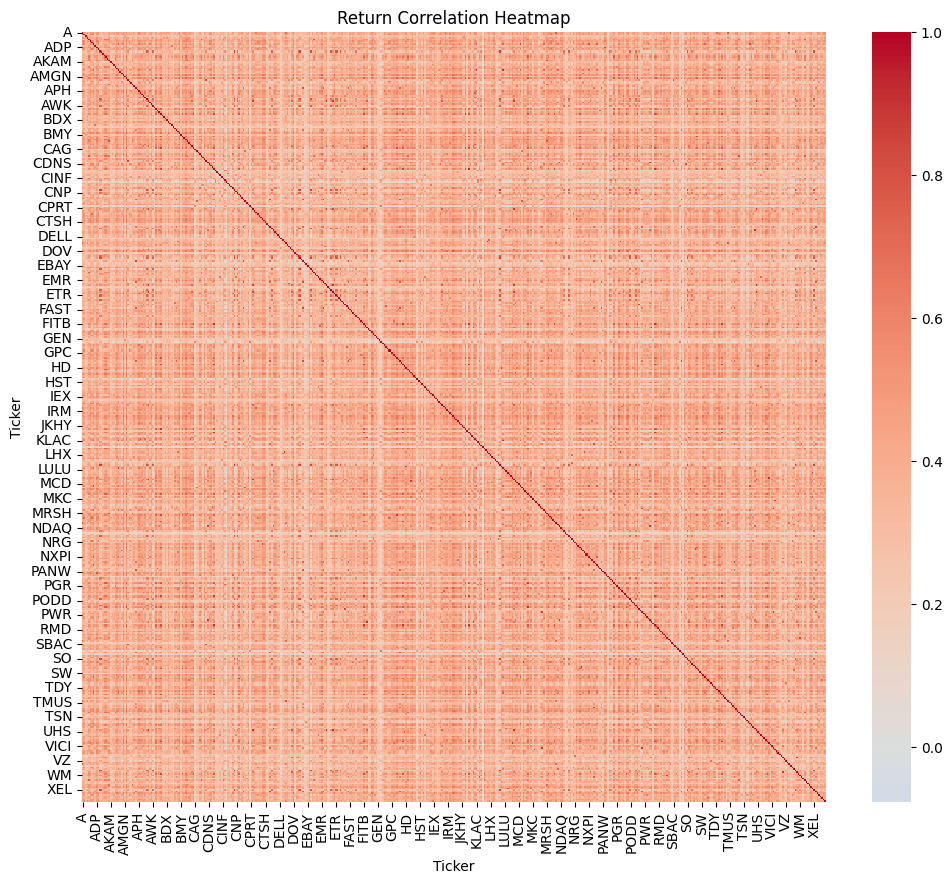

In [615]:
# Correlation matrix of returns
corr_matrix = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Return Correlation Heatmap")
plt.show()

In [616]:
# Convert correlation matrix into pair table safely

corr_matrix_clean = corr_matrix.copy()

# Remove index/column names to avoid reset_index conflict
corr_matrix_clean.index.name = None
corr_matrix_clean.columns.name = None

# Keep only upper triangle so each pair appears once
upper_triangle = corr_matrix_clean.where(
    np.triu(np.ones(corr_matrix_clean.shape), k=1).astype(bool)
)

# Convert to table
corr_pairs = upper_triangle.stack().reset_index()

corr_pairs.columns = ["Stock 1", "Stock 2", "Correlation"]

# Sort from highest to lowest correlation
corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)

corr_pairs.head(20)

,Stock 1,Stock 2,Correlation
93493,GOOG,GOOGL,0.995770
153595,NWS,NWSA,0.974444
74687,EQR,UDR,0.927493
20148,AVB,EQR,0.925543
86996,FRT,REG,0.920478
11217,AMAT,LRCX,0.913594
86046,FITB,RF,0.913453
40164,CFG,FITB,0.912689
136015,MET,PRU,0.911914
20423,AVB,UDR,0.911542


## 6. Feature Engineering

This section prepares the features required for pair identification and signal generation. The cleaned price data is converted into log prices and returns, while sector and subindustry classifications are used to restrict the candidate universe to economically related companies.

Potential pairs are screened using return correlation before their long-run relationship is estimated through cointegration regression. The resulting spread is evaluated using stationarity, half-life, volatility, and hedge-ratio measures. Rolling z-scores are then constructed to measure how far each spread has moved from its recent equilibrium.

Several related signal configurations are defined using different z-score windows, entry thresholds, exit thresholds, stop-loss levels, and maximum holding periods. These features form the inputs to the subsequent validation and portfolio-construction process.

In [332]:
import sys
!{sys.executable} -m pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.0 kB/s  0:00:55 eta 0:00:08m

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
# ============================================================
# SETUP
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import networkx as nx

from tqdm.auto import tqdm
from statsmodels.tsa.stattools import coint, adfuller

# Development period only: 2018 through 2024
DEVELOPMENT_END_EXCLUSIVE = pd.Timestamp("2025-01-01")

prices_bt = prices_clean.loc[
    prices_clean.index < DEVELOPMENT_END_EXCLUSIVE
].copy()

prices_bt.index = pd.to_datetime(prices_bt.index)
prices_bt = prices_bt.sort_index()

# Remove duplicate dates if any exist.
prices_bt = prices_bt.loc[
    ~prices_bt.index.duplicated(keep="first")
]

# Remove assets with missing observations.
prices_bt = prices_bt.dropna(axis=1)

# Prices must be strictly positive before taking logs.
prices_bt = prices_bt.loc[
    :,
    (prices_bt > 0).all(axis=0)
]

log_prices_bt = np.log(prices_bt)

print("Backtest data shape:", prices_bt.shape)
print("Backtest start:", prices_bt.index.min())
print("Backtest end:", prices_bt.index.max())

Backtest data shape: (1761, 476)
Backtest start: 2018-01-02 00:00:00
Backtest end: 2024-12-31 00:00:00


In [618]:
# ------------------------------------------------------------
# Global constants
# ------------------------------------------------------------

TRADING_DAYS = 252


# ------------------------------------------------------------
# Walk-forward structure
# ------------------------------------------------------------

FORMATION_WINDOW = 504
VALIDATION_FOLDS = 3
VALIDATION_FOLD_DAYS = 63

MIN_ESTIMATION_DAYS = (
    FORMATION_WINDOW
    - VALIDATION_FOLDS * VALIDATION_FOLD_DAYS
)

RETRAIN_FREQ = 63


# ------------------------------------------------------------
# Candidate generation
# ------------------------------------------------------------

MAX_CANDIDATES = 800
MIN_CORRELATION = 0.50
USE_SECTOR_FILTER = True


# ------------------------------------------------------------
# Pair-level statistical filters
# ------------------------------------------------------------

MAX_COINTEGRATION_PVALUE = 0.10
MAX_ADF_PVALUE = 0.10

MIN_HALF_LIFE = 3
MAX_HALF_LIFE = 80


# ------------------------------------------------------------
# Multi-fold validation requirements
# ------------------------------------------------------------

MIN_POSITIVE_FOLDS = 2
MIN_VALIDATION_TRADES = 4

MIN_MEDIAN_FOLD_SHARPE = 0.10
MIN_COMBINED_VALIDATION_SHARPE = 0.15
MAX_VALIDATION_DRAWDOWN = -0.10


# ------------------------------------------------------------
# Signal configurations
#
# These are fixed before evaluating the final test periods.
# ------------------------------------------------------------

SIGNAL_CONFIGS = [
    {
        "name": "fast_125",
        "z_window": 40,
        "entry_z": 1.25,
        "exit_z": 0.20,
        "stop_z": 3.50,
        "max_hold": 30
    },
    {
        "name": "medium_150",
        "z_window": 60,
        "entry_z": 1.50,
        "exit_z": 0.25,
        "stop_z": 3.75,
        "max_hold": 40
    },
    {
        "name": "baseline_175",
        "z_window": 60,
        "entry_z": 1.75,
        "exit_z": 0.25,
        "stop_z": 3.75,
        "max_hold": 40
    },
    {
        "name": "slow_200",
        "z_window": 90,
        "entry_z": 2.00,
        "exit_z": 0.30,
        "stop_z": 4.00,
        "max_hold": 50
    }
]


MIN_CONFIG_VALIDATION_SHARPE = 0.00
MIN_CONFIG_POSITIVE_FOLDS = 2
MIN_ACCEPTED_CONFIGS = 1

COOLDOWN_DAYS = 15
TRANSACTION_COST = 0.00005


# ------------------------------------------------------------
# Configuration-weight penalties
# ------------------------------------------------------------

TURNOVER_PENALTY = 1.00
ACTIVE_RATIO_PENALTY = 0.50
MAX_CONFIG_WEIGHT = 0.50


# ------------------------------------------------------------
# Pair selection
# ------------------------------------------------------------

MAX_PAIRS = 20
MIN_PAIRS_REQUIRED = 5
MAX_PAIRS_PER_SECTOR = 3


# ------------------------------------------------------------
# Pair-level portfolio weights
# ------------------------------------------------------------

EQUAL_WEIGHT_BLEND = 0.40
INVERSE_VOL_BLEND = 0.40
QUALITY_WEIGHT_BLEND = 0.20

MAX_PAIR_WEIGHT = 0.10


# ------------------------------------------------------------
# Active-capital scaling
# ------------------------------------------------------------

MIN_ACTIVE_PAIRS_TO_SCALE = 3
TARGET_ACTIVE_CAPITAL = 0.50
MAX_ACTIVE_SCALER = 1.20


# ------------------------------------------------------------
# Successful total-volatility throttle
# ------------------------------------------------------------

THROTTLE_VOL_WINDOW = 20
THROTTLE_HISTORY_WINDOW = 252
THROTTLE_QUANTILE = 0.90
THROTTLE_MIN_EXPOSURE = 0.50

In [619]:
# ------------------------------------------------------------
# Sector and subindustry maps
# ------------------------------------------------------------

def create_classification_maps():
    try:
        table = sp500_table.copy()

        table["Symbol"] = (
            table["Symbol"]
            .astype(str)
            .str.replace(".", "-", regex=False)
        )

        sector_map = (
            table
            .drop_duplicates("Symbol")
            .set_index("Symbol")["GICS Sector"]
            .to_dict()
        )

        if "GICS Sub-Industry" in table.columns:
            subindustry_map = (
                table
                .drop_duplicates("Symbol")
                .set_index("Symbol")["GICS Sub-Industry"]
                .to_dict()
            )
        else:
            subindustry_map = {}

        print("Classification maps created.")

        return sector_map, subindustry_map

    except Exception as exc:
        print("Classification maps unavailable.")
        print("Reason:", exc)

        return {}, {}


sector_map, subindustry_map = create_classification_maps()

Classification maps created.


## 7. Model Building
7.1 Walk-Forward Validation and Configuration Selection

Each candidate pair is evaluated through a quarterly walk-forward procedure. A two-year formation window is divided into an estimation period and three sequential validation folds. Pair parameters are re-estimated before each fold so that validation performance uses only information available at that time.

Each pair is tested under multiple mean-reversion configurations. Configurations are retained only when they demonstrate sufficient trade frequency, positive performance across multiple folds, acceptable drawdown, and a positive combined validation Sharpe ratio. Their weights are based on validation performance while penalizing instability, turnover, and excessive time in the market.

In [ ]:
# ============================================================
# PORTFOLIO METRICS
# ============================================================

def calculate_metrics(
    returns,
    trading_days=TRADING_DAYS
):
    returns = pd.Series(returns).dropna().copy()

    empty_result = pd.Series({
        "Cumulative Return": np.nan,
        "Annualized Return": np.nan,
        "Annualized Volatility": np.nan,
        "Sharpe Ratio": np.nan,
        "Max Drawdown": np.nan,
        "Active-Day Win Rate": np.nan,
        "Active Day Ratio": np.nan
    })

    if returns.empty:
        return empty_result

    active_dates = returns.index[
        returns.ne(0)
    ]

    if len(active_dates) == 0:
        return empty_result

    # Remove the initial formation-period zeros, but retain
    # subsequent inactive/cash days.
    returns = returns.loc[
        active_dates[0]:
    ]

    cumulative_return = (
        (1 + returns).prod() - 1
    )

    annualized_return = (
        (1 + cumulative_return)
        ** (trading_days / len(returns))
        - 1
    )

    daily_volatility = returns.std()

    annualized_volatility = (
        daily_volatility
        * np.sqrt(trading_days)
    )

    if (
        np.isfinite(daily_volatility)
        and daily_volatility > 0
    ):
        sharpe_ratio = (
            returns.mean()
            / daily_volatility
            * np.sqrt(trading_days)
        )
    else:
        sharpe_ratio = np.nan

    wealth = (1 + returns).cumprod()

    drawdown = (
        wealth
        / wealth.cummax()
        - 1
    )

    active_returns = returns[
        returns != 0
    ]

    active_win_rate = (
        (active_returns > 0).mean()
        if len(active_returns) > 0
        else np.nan
    )

    return pd.Series({
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": drawdown.min(),
        "Active-Day Win Rate": active_win_rate,
        "Active Day Ratio": returns.ne(0).mean()
    })

In [ ]:
def calculate_drawdown(returns):
    returns = pd.Series(returns).fillna(0)

    wealth = (1 + returns).cumprod()

    return (
        wealth
        / wealth.cummax()
        - 1
    )


def count_completed_trades(positions):
    positions = (
        pd.Series(positions)
        .fillna(0)
    )

    exits = (
        positions
        .shift(1)
        .fillna(0)
        .ne(0)
        & positions.eq(0)
    )

    return int(exits.sum())

7.2 Pair Selection and Portfolio Construction

Validated pairs are represented as edges in a graph, with their selection scores reflecting performance consistency, risk, turnover, and economic similarity. Maximum-weight matching is used to form a portfolio of non-overlapping pairs so that the same stock cannot appear in multiple positions during one quarter.

The selected pairs are combined using a blend of equal weighting, inverse spread-volatility weighting, and validation-quality weighting. This provides diversification while avoiding excessive dependence on noisy estimates of expected return.

In [ ]:
# ============================================================
# PAIR PARAMETER ESTIMATION
# ============================================================

def estimate_half_life(spread):
    spread = pd.Series(spread).dropna()

    if len(spread) < 80:
        return np.nan

    regression_data = pd.DataFrame({
        "lagged_spread": spread.shift(1),
        "spread_change": spread.diff()
    }).dropna()

    if len(regression_data) < 80:
        return np.nan

    X = sm.add_constant(
        regression_data["lagged_spread"]
    )

    try:
        model = sm.OLS(
            regression_data["spread_change"],
            X
        ).fit()

        coefficient = float(
            model.params["lagged_spread"]
        )

    except Exception:
        return np.nan

    if (
        not np.isfinite(coefficient)
        or coefficient >= 0
    ):
        return np.nan

    half_life = (
        -np.log(2) / coefficient
    )

    return float(half_life)

In [623]:
def estimate_pair_parameters(
    log_window,
    price_window,
    stock1,
    stock2
):
    pair_log = (
        log_window[
            [stock1, stock2]
        ]
        .dropna()
    )

    if len(pair_log) < 100:
        return None

    y = pair_log[stock1]
    x = pair_log[stock2]

    try:
        _, coint_pvalue, _ = coint(
            y,
            x
        )
    except Exception:
        return None

    if (
        not np.isfinite(coint_pvalue)
        or coint_pvalue
        > MAX_COINTEGRATION_PVALUE
    ):
        return None

    try:
        X = sm.add_constant(x)

        model = sm.OLS(
            y,
            X
        ).fit()

        alpha = float(
            model.params.iloc[0]
        )

        beta = float(
            model.params.iloc[1]
        )

    except Exception:
        return None

    if (
        not np.isfinite(beta)
        or beta <= 0
    ):
        return None

    spread = (
        y
        - alpha
        - beta * x
    )

    try:
        (
            adf_statistic,
            adf_pvalue,
            *_
        ) = adfuller(
            spread.dropna()
        )

    except Exception:
        return None

    half_life = estimate_half_life(
        spread
    )

    if (
        not np.isfinite(adf_pvalue)
        or adf_pvalue > MAX_ADF_PVALUE
    ):
        return None

    if (
        not np.isfinite(half_life)
        or half_life < MIN_HALF_LIFE
        or half_life > MAX_HALF_LIFE
    ):
        return None

    pair_returns = (
        price_window[
            [stock1, stock2]
        ]
        .pct_change()
    )

    spread_returns = (
        pair_returns[stock1]
        - beta * pair_returns[stock2]
    ) / (
        1 + abs(beta)
    )

    spread_volatility = (
        spread_returns.std()
        * np.sqrt(TRADING_DAYS)
    )

    if (
        not np.isfinite(spread_volatility)
        or spread_volatility <= 0
    ):
        return None

    return {
        "stock1": stock1,
        "stock2": stock2,
        "alpha": alpha,
        "beta": beta,
        "coint_pvalue": float(coint_pvalue),
        "adf_statistic": float(adf_statistic),
        "adf_pvalue": float(adf_pvalue),
        "half_life": float(half_life),
        "r_squared": float(model.rsquared),
        "spread_volatility": float(
            spread_volatility
        )
    }

In [ ]:
# ============================================================
# CANDIDATE GENERATION
# ============================================================

def generate_candidate_pairs(
    log_window
):
    log_returns = (
        log_window
        .diff()
        .dropna(how="all")
    )

    valid_columns = (
        log_returns
        .std()
        .replace(0, np.nan)
        .dropna()
        .index
    )

    log_returns = log_returns[
        valid_columns
    ]

    if log_returns.shape[1] < 2:
        return pd.DataFrame()

    correlation_matrix = (
        log_returns.corr()
    )

    correlation_matrix.index.name = None
    correlation_matrix.columns.name = None

    upper_triangle = correlation_matrix.where(
        np.triu(
            np.ones(
                correlation_matrix.shape
            ),
            k=1
        ).astype(bool)
    )

    candidates = (
        upper_triangle
        .stack()
        .reset_index()
    )

    candidates.columns = [
        "stock1",
        "stock2",
        "correlation"
    ]

    candidates = candidates[
        candidates["correlation"]
        >= MIN_CORRELATION
    ].copy()

    if candidates.empty:
        return candidates

    if (
        USE_SECTOR_FILTER
        and bool(sector_map)
    ):
        candidates["sector1"] = (
            candidates["stock1"]
            .map(sector_map)
        )

        candidates["sector2"] = (
            candidates["stock2"]
            .map(sector_map)
        )

        candidates = candidates[
            candidates["sector1"]
            .notna()
            & candidates["sector2"]
            .notna()
            & (
                candidates["sector1"]
                == candidates["sector2"]
            )
        ].copy()

        candidates["sector"] = (
            candidates["sector1"]
        )

    else:
        candidates["sector"] = "Unknown"

    if candidates.empty:
        return candidates

    if bool(subindustry_map):
        candidates["same_subindustry"] = (
            candidates["stock1"]
            .map(subindustry_map)
            == candidates["stock2"]
            .map(subindustry_map)
        )
    else:
        candidates["same_subindustry"] = False

    candidates["candidate_score"] = (
        candidates["correlation"]
        + 0.10
        * candidates[
            "same_subindustry"
        ].astype(float)
    )

    candidates = (
        candidates
        .sort_values(
            "candidate_score",
            ascending=False
        )
        .head(MAX_CANDIDATES)
        .reset_index(drop=True)
    )

    return candidates

In [ ]:
# ============================================================
# PARAMETERIZED TRADING RULE
# ============================================================

def generate_positions(
    zscore,
    config
):
    zscore = pd.Series(zscore)

    positions = pd.Series(
        0.0,
        index=zscore.index
    )

    entry_z = float(
        config["entry_z"]
    )

    exit_z = float(
        config["exit_z"]
    )

    stop_z = float(
        config["stop_z"]
    )

    max_hold = int(
        config["max_hold"]
    )

    current_position = 0.0
    holding_days = 0
    cooldown_remaining = 0

    for i, date in enumerate(
        zscore.index
    ):
        z = zscore.iloc[i]

        previous_z = (
            zscore.iloc[i - 1]
            if i > 0
            else np.nan
        )

        if not np.isfinite(z):
            positions.loc[date] = (
                current_position
            )
            continue

        if cooldown_remaining > 0:
            cooldown_remaining -= 1
            current_position = 0.0
            holding_days = 0

            positions.loc[date] = 0.0
            continue

        if current_position == 0:
            if not np.isfinite(previous_z):
                positions.loc[date] = 0.0
                continue

            # Enter only after an extreme spread starts
            # moving back toward its mean.
            if (
                previous_z > entry_z
                and z < previous_z
            ):
                current_position = -1.0
                holding_days = 0

            elif (
                previous_z < -entry_z
                and z > previous_z
            ):
                current_position = 1.0
                holding_days = 0

        elif current_position == 1:
            holding_days += 1

            profit_exit = (
                z >= -exit_z
            )

            stop_exit = (
                z <= -stop_z
            )

            time_exit = (
                holding_days >= max_hold
            )

            if (
                profit_exit
                or stop_exit
                or time_exit
            ):
                current_position = 0.0
                holding_days = 0

                if stop_exit:
                    cooldown_remaining = (
                        COOLDOWN_DAYS
                    )

        elif current_position == -1:
            holding_days += 1

            profit_exit = (
                z <= exit_z
            )

            stop_exit = (
                z >= stop_z
            )

            time_exit = (
                holding_days >= max_hold
            )

            if (
                profit_exit
                or stop_exit
                or time_exit
            ):
                current_position = 0.0
                holding_days = 0

                if stop_exit:
                    cooldown_remaining = (
                        COOLDOWN_DAYS
                    )

        positions.loc[date] = (
            current_position
        )

    return positions

In [626]:
def backtest_pair_config(
    log_prices,
    prices,
    pair_parameters,
    history_start,
    trade_start,
    trade_end,
    config
):
    stock1 = pair_parameters[
        "stock1"
    ]

    stock2 = pair_parameters[
        "stock2"
    ]

    alpha = float(
        pair_parameters["alpha"]
    )

    beta = float(
        pair_parameters["beta"]
    )

    pair_log = (
        log_prices
        .loc[
            history_start:trade_end,
            [stock1, stock2]
        ]
        .dropna()
    )

    pair_prices = (
        prices
        .loc[
            history_start:trade_end,
            [stock1, stock2]
        ]
        .dropna()
    )

    z_window = int(
        config["z_window"]
    )

    if len(pair_log) < z_window + 20:
        return (
            pd.Series(dtype=float),
            pd.Series(dtype=float)
        )

    spread = (
        pair_log[stock1]
        - alpha
        - beta * pair_log[stock2]
    )

    rolling_mean = (
        spread
        .rolling(z_window)
        .mean()
        .shift(1)
    )

    rolling_std = (
        spread
        .rolling(z_window)
        .std()
        .shift(1)
        .replace(0, np.nan)
    )

    zscore = (
        (spread - rolling_mean)
        / rolling_std
    )

    zscore = zscore.loc[
        trade_start:trade_end
    ]

    positions = generate_positions(
        zscore=zscore,
        config=config
    )

    stock_returns = (
        pair_prices
        .pct_change()
    )

    spread_returns = (
        stock_returns[stock1]
        - beta * stock_returns[stock2]
    ) / (
        1 + abs(beta)
    )

    spread_returns = (
        spread_returns
        .reindex(positions.index)
    )

    # Position decided at the end of day t is applied
    # to the return on day t+1.
    gross_returns = (
        positions
        .shift(1)
        .fillna(0)
        * spread_returns
    )

    turnover = (
        positions
        .diff()
        .abs()
        .fillna(
            positions.abs()
        )
    )

    transaction_costs = (
        turnover
        * TRANSACTION_COST
    )

    net_returns = (
        gross_returns
        - transaction_costs
    ).fillna(0)

    return net_returns, positions

In [ ]:
# ============================================================
# MULTI-FOLD CONFIGURATION VALIDATION
# ============================================================

def validate_pair_configuration(
    log_prices,
    prices,
    stock1,
    stock2,
    formation_dates,
    config
):
    fold_rows = []
    combined_return_series = []

    total_turnover = 0.0
    total_observations = 0

    for fold_number in range(
        VALIDATION_FOLDS
    ):
        fold_start_position = (
            MIN_ESTIMATION_DAYS
            + fold_number
            * VALIDATION_FOLD_DAYS
        )

        fold_end_position = min(
            fold_start_position
            + VALIDATION_FOLD_DAYS
            - 1,
            len(formation_dates) - 1
        )

        estimation_start = (
            formation_dates[0]
        )

        estimation_end = (
            formation_dates[
                fold_start_position - 1
            ]
        )

        fold_start = (
            formation_dates[
                fold_start_position
            ]
        )

        fold_end = (
            formation_dates[
                fold_end_position
            ]
        )

        estimation_log = (
            log_prices.loc[
                estimation_start:
                estimation_end
            ]
        )

        estimation_prices = (
            prices.loc[
                estimation_start:
                estimation_end
            ]
        )

        parameters = (
            estimate_pair_parameters(
                log_window=estimation_log,
                price_window=estimation_prices,
                stock1=stock1,
                stock2=stock2
            )
        )

        if parameters is None:
            return None

        (
            fold_returns,
            fold_positions
        ) = backtest_pair_config(
            log_prices=log_prices,
            prices=prices,
            pair_parameters=parameters,
            history_start=estimation_start,
            trade_start=fold_start,
            trade_end=fold_end,
            config=config
        )

        if fold_returns.empty:
            return None

        metrics = calculate_metrics(
            fold_returns
        )

        turnover = (
            fold_positions
            .diff()
            .abs()
            .fillna(
                fold_positions.abs()
            )
        )

        total_turnover += (
            turnover.sum()
        )

        total_observations += len(
            turnover
        )

        fold_rows.append({
            "fold": fold_number + 1,
            "sharpe": metrics[
                "Sharpe Ratio"
            ],
            "return": metrics[
                "Cumulative Return"
            ],
            "drawdown": metrics[
                "Max Drawdown"
            ],
            "trades": (
                count_completed_trades(
                    fold_positions
                )
            ),
            "active_ratio": (
                fold_positions
                .ne(0)
                .mean()
            )
        })

        combined_return_series.append(
            fold_returns
        )

    fold_table = pd.DataFrame(
        fold_rows
    )

    if fold_table.empty:
        return None

    combined_returns = (
        pd.concat(
            combined_return_series
        )
        .sort_index()
    )

    combined_metrics = (
        calculate_metrics(
            combined_returns
        )
    )

    turnover_rate = (
        total_turnover
        / total_observations
        if total_observations > 0
        else np.nan
    )

    return {
        "config_name": config["name"],
        "positive_folds": int(
            (
                fold_table["return"]
                > 0
            ).sum()
        ),
        "total_trades": int(
            fold_table["trades"].sum()
        ),
        "median_fold_sharpe": float(
            fold_table["sharpe"].median()
        ),
        "fold_sharpe_std": float(
            fold_table["sharpe"].std()
        ),
        "combined_sharpe": float(
            combined_metrics[
                "Sharpe Ratio"
            ]
        ),
        "combined_return": float(
            combined_metrics[
                "Cumulative Return"
            ]
        ),
        "combined_drawdown": float(
            combined_metrics[
                "Max Drawdown"
            ]
        ),
        "active_ratio": float(
            fold_table[
                "active_ratio"
            ].mean()
        ),
        "turnover_rate": float(
            turnover_rate
        )
    }

7.3 Signal Ensemble and Rolling Backtest

For each selected pair, the accepted signal configurations are retained as separate sub-strategies and combined using their validation-derived weights. Signals are shifted before being applied to returns to avoid look-ahead bias, and transaction costs are deducted whenever positions change.

The complete portfolio is rebuilt every 63 trading days. Pair relationships, accepted configurations, pair weights, and portfolio exposure are therefore updated using a rolling two-year formation sample.

In [ ]:
# ============================================================
# PAIR-LEVEL ENSEMBLE VALIDATION
# ============================================================

def cap_and_redistribute_weights(
    weights,
    maximum_weight
):
    weights = (
        pd.Series(weights)
        .astype(float)
        .clip(lower=0)
    )

    if weights.sum() <= 0:
        weights[:] = 1.0

    weights /= weights.sum()

    # This cap is feasible for the four signal
    # configurations because max weight is 50%.
    for _ in range(20):
        over_cap = (
            weights > maximum_weight
        )

        if not over_cap.any():
            break

        excess = (
            weights.loc[over_cap]
            - maximum_weight
        ).sum()

        weights.loc[over_cap] = (
            maximum_weight
        )

        under_cap = (
            weights < maximum_weight
        )

        if (
            not under_cap.any()
            or weights.loc[
                under_cap
            ].sum() <= 0
        ):
            break

        weights.loc[under_cap] += (
            weights.loc[under_cap]
            / weights.loc[
                under_cap
            ].sum()
            * excess
        )

    weights /= weights.sum()

    return weights

In [629]:
def validate_pair_ensemble(
    log_prices,
    prices,
    stock1,
    stock2,
    formation_dates
):
    configuration_results = []

    for config in SIGNAL_CONFIGS:
        result = (
            validate_pair_configuration(
                log_prices=log_prices,
                prices=prices,
                stock1=stock1,
                stock2=stock2,
                formation_dates=formation_dates,
                config=config
            )
        )

        if result is not None:
            configuration_results.append(
                result
            )

    if not configuration_results:
        return None

    config_table = pd.DataFrame(
        configuration_results
    )

    accepted = config_table[
        (
            config_table[
                "positive_folds"
            ]
            >= MIN_CONFIG_POSITIVE_FOLDS
        )
        & (
            config_table[
                "total_trades"
            ]
            >= MIN_VALIDATION_TRADES
        )
        & (
            config_table[
                "combined_sharpe"
            ]
            >= MIN_CONFIG_VALIDATION_SHARPE
        )
        & (
            config_table[
                "combined_drawdown"
            ]
            >= MAX_VALIDATION_DRAWDOWN
        )
    ].copy()

    if len(accepted) < MIN_ACCEPTED_CONFIGS:
        return None

    pair_positive_folds = float(
        accepted[
            "positive_folds"
        ].median()
    )

    pair_trades = float(
        accepted[
            "total_trades"
        ].median()
    )

    pair_median_sharpe = float(
        accepted[
            "median_fold_sharpe"
        ].median()
    )

    pair_combined_sharpe = float(
        accepted[
            "combined_sharpe"
        ].median()
    )

    pair_drawdown = float(
        accepted[
            "combined_drawdown"
        ].median()
    )

    if (
        pair_positive_folds
        < MIN_POSITIVE_FOLDS
    ):
        return None

    if pair_trades < MIN_VALIDATION_TRADES:
        return None

    if (
        not np.isfinite(
            pair_median_sharpe
        )
        or pair_median_sharpe
        < MIN_MEDIAN_FOLD_SHARPE
    ):
        return None

    if (
        not np.isfinite(
            pair_combined_sharpe
        )
        or pair_combined_sharpe
        < MIN_COMBINED_VALIDATION_SHARPE
    ):
        return None

    if (
        not np.isfinite(pair_drawdown)
        or pair_drawdown
        < MAX_VALIDATION_DRAWDOWN
    ):
        return None

    instability_penalty = (
        1
        + accepted[
            "fold_sharpe_std"
        ]
        .fillna(0)
        .clip(lower=0)
    )

    turnover_penalty = (
        1
        + TURNOVER_PENALTY
        * accepted[
            "turnover_rate"
        ]
        .fillna(0)
        .clip(lower=0)
    )

    activity_penalty = (
        1
        + ACTIVE_RATIO_PENALTY
        * accepted[
            "active_ratio"
        ]
        .fillna(0)
        .clip(lower=0)
    )

    raw_weights = (
        accepted[
            "combined_sharpe"
        ]
        .clip(lower=0)
        / (
            instability_penalty
            * turnover_penalty
            * activity_penalty
        )
    )

    raw_weights = (
        cap_and_redistribute_weights(
            weights=raw_weights,
            maximum_weight=MAX_CONFIG_WEIGHT
        )
    )

    accepted["config_weight"] = (
        raw_weights.values
    )

    return {
        "stock1": stock1,
        "stock2": stock2,
        "positive_folds": (
            pair_positive_folds
        ),
        "validation_trades": (
            pair_trades
        ),
        "median_fold_sharpe": (
            pair_median_sharpe
        ),
        "combined_validation_sharpe": (
            pair_combined_sharpe
        ),
        "validation_drawdown": (
            pair_drawdown
        ),
        "accepted_config_count": int(
            len(accepted)
        ),
        "median_turnover_rate": float(
            accepted[
                "turnover_rate"
            ].median()
        ),
        "median_active_ratio": float(
            accepted[
                "active_ratio"
            ].median()
        ),
        "config_table": (
            accepted[
                [
                    "config_name",
                    "config_weight"
                ]
            ]
            .reset_index(drop=True)
        )
    }

In [ ]:
# ============================================================
# VALIDATED MAXIMUM-WEIGHT MATCHING
# ============================================================

def select_validated_pairs(
    validated_pairs
):
    if validated_pairs.empty:
        return pd.DataFrame()

    graph = nx.Graph()

    for row_index, row in (
        validated_pairs.iterrows()
    ):
        stock1 = row["stock1"]
        stock2 = row["stock2"]

        same_subindustry = (
            bool(subindustry_map)
            and subindustry_map.get(stock1)
            == subindustry_map.get(stock2)
        )

        selection_score = (
            row[
                "combined_validation_sharpe"
            ]
            + 0.30
            * row[
                "median_fold_sharpe"
            ]
            + 0.10
            * row[
                "positive_folds"
            ]
            + 0.05
            * row[
                "accepted_config_count"
            ]
            + 0.30
            * row[
                "validation_drawdown"
            ]
            - 0.20
            * row[
                "median_turnover_rate"
            ]
            + 0.10
            * float(same_subindustry)
        )

        if (
            not np.isfinite(
                selection_score
            )
            or selection_score <= 0
        ):
            continue

        graph.add_edge(
            stock1,
            stock2,
            weight=float(
                selection_score
            ),
            row_index=row_index
        )

    if graph.number_of_edges() == 0:
        return pd.DataFrame()

    matching = (
        nx.algorithms.matching
        .max_weight_matching(
            graph,
            maxcardinality=False,
            weight="weight"
        )
    )

    matched_rows = []

    for stock1, stock2 in matching:
        edge_data = (
            graph.get_edge_data(
                stock1,
                stock2
            )
        )

        row = validated_pairs.loc[
            edge_data["row_index"]
        ].copy()

        row["selection_score"] = (
            edge_data["weight"]
        )

        row["sector"] = (
            sector_map.get(
                stock1,
                "Unknown"
            )
        )

        matched_rows.append(row)

    if not matched_rows:
        return pd.DataFrame()

    matched = (
        pd.DataFrame(matched_rows)
        .sort_values(
            "selection_score",
            ascending=False
        )
    )

    selected_rows = []
    sector_counts = {}

    for _, row in matched.iterrows():
        sector = row["sector"]

        if (
            sector_counts.get(
                sector,
                0
            )
            >= MAX_PAIRS_PER_SECTOR
        ):
            continue

        selected_rows.append(row)

        sector_counts[sector] = (
            sector_counts.get(
                sector,
                0
            )
            + 1
        )

        if (
            len(selected_rows)
            >= MAX_PAIRS
        ):
            break

    if len(selected_rows) < MIN_PAIRS_REQUIRED:
        return pd.DataFrame()

    return (
        pd.DataFrame(selected_rows)
        .reset_index(drop=True)
    )

In [ ]:
# ============================================================
# PAIR WEIGHTS
# ============================================================

def normalize_positive_weights(
    values
):
    values = (
        pd.Series(values)
        .astype(float)
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0)
        .clip(lower=0)
    )

    if values.sum() <= 0:
        return pd.Series(
            1 / len(values),
            index=values.index
        )

    return values / values.sum()

In [632]:
def calculate_pair_weights(
    selected_pairs
):
    number_of_pairs = len(
        selected_pairs
    )

    equal_weights = pd.Series(
        1 / number_of_pairs,
        index=selected_pairs.index,
        dtype=float
    )

    inverse_volatility = (
        1
        / selected_pairs[
            "spread_volatility"
        ].replace(0, np.nan)
    )

    inverse_volatility = (
        normalize_positive_weights(
            inverse_volatility
        )
    )

    quality_weights = (
        normalize_positive_weights(
            selected_pairs[
                "combined_validation_sharpe"
            ]
        )
    )

    weights = (
        EQUAL_WEIGHT_BLEND
        * equal_weights
        + INVERSE_VOL_BLEND
        * inverse_volatility
        + QUALITY_WEIGHT_BLEND
        * quality_weights
    )

    # Keep the same soft-cap behavior used in the
    # successful tested version.
    for _ in range(20):
        over_cap = (
            weights > MAX_PAIR_WEIGHT
        )

        if not over_cap.any():
            break

        excess = (
            weights.loc[over_cap]
            - MAX_PAIR_WEIGHT
        ).sum()

        weights.loc[over_cap] = (
            MAX_PAIR_WEIGHT
        )

        under_cap = (
            weights < MAX_PAIR_WEIGHT
        )

        if (
            not under_cap.any()
            or weights.loc[
                under_cap
            ].sum() <= 0
        ):
            break

        weights.loc[under_cap] += (
            weights.loc[under_cap]
            / weights.loc[
                under_cap
            ].sum()
            * excess
        )

    weights /= weights.sum()

    return weights

In [ ]:
# ============================================================
# TEST-PERIOD CONFIGURATION ENSEMBLE
# ============================================================

def backtest_pair_ensemble(
    log_prices,
    prices,
    pair_row,
    history_start,
    trade_start,
    trade_end
):
    config_lookup = {
        config["name"]: config
        for config in SIGNAL_CONFIGS
    }

    config_return_series = []
    config_position_series = []
    config_weights = []

    config_table = pair_row[
        "config_table"
    ]

    for _, config_row in (
        config_table.iterrows()
    ):
        config_name = (
            config_row["config_name"]
        )

        if config_name not in config_lookup:
            continue

        config = config_lookup[
            config_name
        ]

        (
            config_returns,
            config_positions
        ) = backtest_pair_config(
            log_prices=log_prices,
            prices=prices,
            pair_parameters=pair_row,
            history_start=history_start,
            trade_start=trade_start,
            trade_end=trade_end,
            config=config
        )

        if config_returns.empty:
            continue

        config_return_series.append(
            config_returns
        )

        config_position_series.append(
            config_positions
        )

        config_weights.append(
            float(
                config_row[
                    "config_weight"
                ]
            )
        )

    if not config_return_series:
        return (
            pd.Series(dtype=float),
            pd.Series(dtype=float)
        )

    weights = np.asarray(
        config_weights,
        dtype=float
    )

    if (
        not np.isfinite(weights).all()
        or weights.sum() <= 0
    ):
        weights = np.repeat(
            1 / len(weights),
            len(weights)
        )
    else:
        weights /= weights.sum()

    return_frame = pd.concat(
        config_return_series,
        axis=1
    ).fillna(0)

    position_frame = pd.concat(
        config_position_series,
        axis=1
    ).fillna(0)

    ensemble_returns = (
        return_frame
        .mul(weights, axis=1)
        .sum(axis=1)
    )

    # Fraction of configuration capital currently active.
    ensemble_exposure = (
        position_frame
        .abs()
        .mul(weights, axis=1)
        .sum(axis=1)
    )

    return (
        ensemble_returns,
        ensemble_exposure
    )

In [ ]:
# ============================================================
# ROLLING QUARTERLY BACKTEST
# ============================================================

def rolling_ensemble_pairs_backtest(
    log_prices,
    prices
):
    all_dates = log_prices.index

    portfolio_returns = pd.Series(
        0.0,
        index=all_dates,
        dtype=float
    )

    selected_history = []
    segment_history = []

    rebalance_indices = list(
        range(
            FORMATION_WINDOW,
            len(all_dates),
            RETRAIN_FREQ
        )
    )

    for rebalance_index in tqdm(
        rebalance_indices,
        desc="Quarterly walk-forward backtest"
    ):
        formation_dates = all_dates[
            rebalance_index
            - FORMATION_WINDOW:
            rebalance_index
        ]

        if len(formation_dates) < FORMATION_WINDOW:
            continue

        formation_start = (
            formation_dates[0]
        )

        formation_end = (
            formation_dates[-1]
        )

        test_start = all_dates[
            rebalance_index
        ]

        test_end_index = min(
            rebalance_index
            + RETRAIN_FREQ
            - 1,
            len(all_dates) - 1
        )

        test_end = all_dates[
            test_end_index
        ]

        initial_estimation_end = (
            formation_dates[
                MIN_ESTIMATION_DAYS - 1
            ]
        )

        initial_log = (
            log_prices.loc[
                formation_start:
                initial_estimation_end
            ]
        )

        candidates = (
            generate_candidate_pairs(
                initial_log
            )
        )

        if candidates.empty:
            continue

        validated_rows = []

        for _, candidate in (
            candidates.iterrows()
        ):
            result = validate_pair_ensemble(
                log_prices=log_prices,
                prices=prices,
                stock1=candidate[
                    "stock1"
                ],
                stock2=candidate[
                    "stock2"
                ],
                formation_dates=formation_dates
            )

            if result is not None:
                validated_rows.append(
                    result
                )

        validated_pairs = pd.DataFrame(
            validated_rows
        )

        if validated_pairs.empty:
            continue

        selected_pairs = (
            select_validated_pairs(
                validated_pairs
            )
        )

        if (
            selected_pairs.empty
            or len(selected_pairs)
            < MIN_PAIRS_REQUIRED
        ):
            continue

        full_formation_log = (
            log_prices.loc[
                formation_start:
                formation_end
            ]
        )

        full_formation_prices = (
            prices.loc[
                formation_start:
                formation_end
            ]
        )

        updated_rows = []

        for _, row in (
            selected_pairs.iterrows()
        ):
            parameters = (
                estimate_pair_parameters(
                    log_window=(
                        full_formation_log
                    ),
                    price_window=(
                        full_formation_prices
                    ),
                    stock1=row["stock1"],
                    stock2=row["stock2"]
                )
            )

            if parameters is None:
                continue

            combined = row.to_dict()
            combined.update(parameters)

            updated_rows.append(
                combined
            )

        selected_pairs = pd.DataFrame(
            updated_rows
        )

        if (
            selected_pairs.empty
            or len(selected_pairs)
            < MIN_PAIRS_REQUIRED
        ):
            continue

        pair_weights = (
            calculate_pair_weights(
                selected_pairs
            )
        )

        pair_return_series = []
        pair_exposure_series = []
        surviving_weights = []
        surviving_pair_indices = []

        for pair_index, pair in (
            selected_pairs.iterrows()
        ):
            (
                pair_returns,
                pair_exposure
            ) = backtest_pair_ensemble(
                log_prices=log_prices,
                prices=prices,
                pair_row=pair,
                history_start=formation_start,
                trade_start=test_start,
                trade_end=test_end
            )

            if pair_returns.empty:
                continue

            pair_name = (
                f"{pair['stock1']}-"
                f"{pair['stock2']}"
            )

            pair_returns.name = pair_name
            pair_exposure.name = pair_name

            pair_return_series.append(
                pair_returns
            )

            pair_exposure_series.append(
                pair_exposure
            )

            surviving_weights.append(
                pair_weights.loc[
                    pair_index
                ]
            )

            surviving_pair_indices.append(
                pair_index
            )

        if (
            len(pair_return_series)
            < MIN_PAIRS_REQUIRED
        ):
            continue

        returns_frame = pd.concat(
            pair_return_series,
            axis=1
        ).fillna(0)

        exposure_frame = pd.concat(
            pair_exposure_series,
            axis=1
        ).fillna(0)

        fixed_weights = pd.Series(
            surviving_weights,
            index=returns_frame.columns,
            dtype=float
        )

        if fixed_weights.sum() <= 0:
            fixed_weights[:] = (
                1 / len(fixed_weights)
            )
        else:
            fixed_weights /= (
                fixed_weights.sum()
            )

        base_returns = (
            returns_frame
            .mul(
                fixed_weights,
                axis=1
            )
            .sum(axis=1)
        )

        active_pair_count = (
            exposure_frame
            .gt(0)
            .sum(axis=1)
        )

        active_capital = (
            exposure_frame
            .mul(
                fixed_weights,
                axis=1
            )
            .sum(axis=1)
        )

        desired_scaler = (
            TARGET_ACTIVE_CAPITAL
            / active_capital.replace(
                0,
                np.nan
            )
        )

        desired_scaler = (
            desired_scaler
            .clip(
                lower=1.0,
                upper=MAX_ACTIVE_SCALER
            )
            .fillna(0.0)
        )

        scaler = pd.Series(
            1.0,
            index=base_returns.index,
            dtype=float
        )

        scaling_allowed = (
            active_pair_count
            >= MIN_ACTIVE_PAIRS_TO_SCALE
        )

        scaler.loc[
            scaling_allowed
        ] = desired_scaler.loc[
            scaling_allowed
        ]

        scaler.loc[
            active_pair_count == 0
        ] = 0.0

        segment_returns = (
            base_returns
            * scaler
        )

        portfolio_returns.loc[
            segment_returns.index
        ] = segment_returns

        selected_pairs = (
            selected_pairs.loc[
                surviving_pair_indices
            ]
            .copy()
            .reset_index(drop=True)
        )

        selected_pairs[
            "pair_weight"
        ] = fixed_weights.values

        selected_pairs[
            "rebalance_date"
        ] = test_start

        selected_pairs[
            "test_start"
        ] = test_start

        selected_pairs[
            "test_end"
        ] = test_end

        selected_history.append(
            selected_pairs
        )

        segment_history.append({
            "rebalance_date": test_start,
            "test_end": test_end,
            "candidate_pairs": len(
                candidates
            ),
            "validated_pairs": len(
                validated_pairs
            ),
            "selected_pairs": len(
                selected_pairs
            ),
            "average_active_pairs": float(
                active_pair_count.mean()
            ),
            "average_active_capital": float(
                active_capital.mean()
            ),
            "average_scaler": float(
                scaler.mean()
            ),
            "median_validation_sharpe": float(
                selected_pairs[
                    "combined_validation_sharpe"
                ].median()
            )
        })

    if selected_history:
        selected_history = pd.concat(
            selected_history,
            ignore_index=True
        )
    else:
        selected_history = pd.DataFrame()

    segment_history = pd.DataFrame(
        segment_history
    )

    return (
        portfolio_returns,
        selected_history,
        segment_history
    )

7.4 Portfolio Risk Control

A volatility-based exposure throttle is applied to the completed portfolio. Recent realized volatility is compared with its own trailing historical distribution. When volatility becomes unusually high, exposure is reduced, but it is never increased above the original portfolio allocation.

This overlay is separated from the underlying trading model so that its contribution can be evaluated directly against the unthrottled ensemble.

In [ ]:
# ============================================================
# SUCCESSFUL DOWNSIDE-ONLY TOTAL-VOLATILITY THROTTLE
# ============================================================

def apply_total_volatility_throttle(
    returns,
    short_window=THROTTLE_VOL_WINDOW,
    history_window=THROTTLE_HISTORY_WINDOW,
    stress_quantile=THROTTLE_QUANTILE,
    minimum_exposure=THROTTLE_MIN_EXPOSURE
):
    """
    Reduce exposure when recent realized portfolio volatility is
    unusually high relative to the portfolio's own trailing history.

    The overlay is causal:
    every risk estimate is shifted by one day.

    Exposure is always between minimum_exposure and 1.
    The function can reduce risk but cannot introduce leverage.
    """
    returns = (
        pd.Series(returns)
        .fillna(0)
        .copy()
    )

    realized_volatility = (
        returns
        .rolling(
            short_window,
            min_periods=10
        )
        .std()
        .shift(1)
        * np.sqrt(TRADING_DAYS)
    )

    stress_threshold = (
        realized_volatility
        .rolling(
            history_window,
            min_periods=60
        )
        .quantile(
            stress_quantile
        )
        .shift(1)
    )

    exposure = (
        stress_threshold
        / realized_volatility.replace(
            0,
            np.nan
        )
    )

    exposure = (
        exposure
        .clip(
            lower=minimum_exposure,
            upper=1.0
        )
        .fillna(1.0)
    )

    throttled_returns = (
        returns
        * exposure
    )

    diagnostics = pd.DataFrame({
        "realized_volatility": (
            realized_volatility
        ),
        "stress_threshold": (
            stress_threshold
        ),
        "exposure": exposure,
        "stress": (
            realized_volatility
            > stress_threshold
        ).fillna(False)
    })

    return (
        throttled_returns,
        exposure,
        diagnostics
    )

## 8. Model Evaluation
8.1 Performance Measurement

The strategy is evaluated at the aggregate portfolio level rather than by emphasizing the results of individual pairs. The primary metrics are cumulative return, annualized return, annualized volatility, Sharpe ratio, maximum drawdown, active-day win rate, and active-day ratio.

The turnover-aware ensemble and the volatility-throttled portfolio are reported separately. This comparison shows whether the risk overlay improves performance without changing the underlying pair-selection and trading process.

In [ ]:
# ============================================================
# RUN THE COMPLETE STRATEGY
# ============================================================

(
    turnover_aware_returns,
    selected_pairs_history,
    segment_history
) = rolling_ensemble_pairs_backtest(
    log_prices=log_prices_bt,
    prices=prices_bt
)

Quarterly walk-forward backtest: 100%|██████████| 20/20 [06:58<00:00, 20.93s/it]


In [637]:
(
    final_portfolio_returns,
    throttle_exposure,
    throttle_diagnostics
) = apply_total_volatility_throttle(
    returns=turnover_aware_returns
)

In [638]:
strategy_comparison = pd.DataFrame({
    "Turnover-Aware Ensemble": (
        calculate_metrics(
            turnover_aware_returns
        )
    ),
    "Turnover-Aware + Vol Throttle": (
        calculate_metrics(
            final_portfolio_returns
        )
    )
}).T

display(
    strategy_comparison.round(6)
)

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active-Day Win Rate,Active Day Ratio
Turnover-Aware Ensemble,0.087236,0.016923,0.024886,0.686755,-0.030098,0.472065,0.98328
Turnover-Aware + Vol Throttle,0.094192,0.018225,0.023082,0.794005,-0.019327,0.472065,0.98328


In [639]:
# Main reported strategy

final_metrics = calculate_metrics(
    final_portfolio_returns
)

print("Final reported strategy:")
print(
    "Turnover-Aware Multi-Configuration "
    "Pairs Portfolio + Total-Volatility Throttle"
)

display(final_metrics)

Final reported strategy:
Turnover-Aware Multi-Configuration Pairs Portfolio + Total-Volatility Throttle


Cumulative Return        0.094192
Annualized Return        0.018225
Annualized Volatility    0.023082
Sharpe Ratio             0.794005
Max Drawdown            -0.019327
Active-Day Win Rate      0.472065
Active Day Ratio         0.983280
dtype: float64

In [ ]:
# ============================================================
# EXACT PERFORMANCE COMPARISON
# ============================================================

raw_sharpe = strategy_comparison.loc[
    "Turnover-Aware Ensemble",
    "Sharpe Ratio"
]

throttled_sharpe = strategy_comparison.loc[
    "Turnover-Aware + Vol Throttle",
    "Sharpe Ratio"
]

raw_drawdown = strategy_comparison.loc[
    "Turnover-Aware Ensemble",
    "Max Drawdown"
]

throttled_drawdown = (
    strategy_comparison.loc[
        "Turnover-Aware + Vol Throttle",
        "Max Drawdown"
    ]
)

print(
    f"Unthrottled Sharpe: {raw_sharpe:.6f}"
)

print(
    f"Throttled Sharpe:   {throttled_sharpe:.6f}"
)

print(
    f"Absolute change:    "
    f"{throttled_sharpe - raw_sharpe:+.6f}"
)

if (
    np.isfinite(raw_sharpe)
    and raw_sharpe != 0
):
    print(
        f"Relative change:    "
        f"{100 * (throttled_sharpe / raw_sharpe - 1):+.2f}%"
    )

print(
    f"\nUnthrottled drawdown: "
    f"{raw_drawdown:.4%}"
)

print(
    f"Throttled drawdown:   "
    f"{throttled_drawdown:.4%}"
)

print(
    f"Drawdown change:       "
    f"{throttled_drawdown - raw_drawdown:+.4%}"
)

Unthrottled Sharpe: 0.686755
Throttled Sharpe:   0.794005
Absolute change:    +0.107250
Relative change:    +15.62%

Unthrottled drawdown: -3.0098%
Throttled drawdown:   -1.9327%
Drawdown change:       +1.0771%


8.2 Walk-Forward and Portfolio Diagnostics

Quarter-level diagnostics are used to examine how the portfolio is formed over time. These include the number of candidate, validated, selected, and active pairs; the proportion of active capital; and the portfolio scaling multiplier.

Additional diagnostics summarize the use and weight of each signal configuration, the sector distribution of selected pairs, validation quality, turnover, pair-weight concentration, and the frequency with which the volatility throttle reduces exposure. These checks help determine whether the final performance is broadly diversified or driven by a small subset of pairs or market periods.

In [ ]:
# ============================================================
# WALK-FORWARD DIAGNOSTICS
# ============================================================

print("Quarters traded:")
print(len(segment_history))

if not segment_history.empty:
    print("\nAverage candidate pairs:")
    print(
        segment_history[
            "candidate_pairs"
        ].mean()
    )

    print("\nAverage validated pairs:")
    print(
        segment_history[
            "validated_pairs"
        ].mean()
    )

    print("\nAverage selected pairs:")
    print(
        segment_history[
            "selected_pairs"
        ].mean()
    )

    print("\nAverage active pairs:")
    print(
        segment_history[
            "average_active_pairs"
        ].mean()
    )

    print("\nAverage active capital:")
    print(
        segment_history[
            "average_active_capital"
        ].mean()
    )

    print("\nAverage internal scaler:")
    print(
        segment_history[
            "average_scaler"
        ].mean()
    )

Quarters traded:
20

Average candidate pairs:
800.0

Average validated pairs:
33.95

Average selected pairs:
12.15

Average active pairs:
7.4642857142857135

Average active capital:
0.48565260194030513

Average internal scaler:
1.0537988897040373


In [642]:
display(
    segment_history
)

,rebalance_date,test_end,candidate_pairs,validated_pairs,selected_pairs,average_active_pairs,average_active_capital,average_scaler,median_validation_sharpe
0,2020-01-03,2020-04-02,800,42,10,5.444444,0.434501,1.064231,1.963281
1,2020-04-03,2020-07-02,800,25,7,5.095238,0.527685,1.022183,1.337123
2,2020-07-06,2020-10-01,800,20,7,4.571429,0.394025,1.107028,1.152294
3,2020-10-02,2020-12-31,800,26,10,5.936508,0.449117,1.050130,1.629512
4,2021-01-04,2021-04-05,800,13,5,3.555556,0.601509,1.027106,1.799472
5,2021-04-06,2021-07-02,800,30,14,9.952381,0.568438,1.011242,1.744715
6,2021-07-06,2021-10-01,800,37,14,8.904762,0.491430,1.029953,1.855174
7,2021-10-04,2021-12-31,800,39,19,10.634921,0.414926,1.091435,1.598656
8,2022-01-03,2022-04-01,800,53,14,7.333333,0.434320,1.098533,1.070350
9,2022-04-04,2022-07-05,800,121,20,11.587302,0.468751,1.057861,1.895246


In [643]:
if not segment_history.empty:
    display(
        segment_history.describe(
            include="all"
        )
    )

,rebalance_date,test_end,candidate_pairs,validated_pairs,selected_pairs,average_active_pairs,average_active_capital,average_scaler,median_validation_sharpe
count,20,20,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2022-05-21 03:36:00,2022-08-18 10:48:00,800.0,33.950000,12.150000,7.464286,0.485653,1.053799,1.500802
min,2020-01-03 00:00:00,2020-04-02 00:00:00,800.0,13.000000,5.000000,3.555556,0.394025,1.011242,1.042276
25%,2021-03-14 00:00:00,2021-06-10 00:00:00,800.0,25.000000,10.000000,5.611111,0.434456,1.027624,1.175095
50%,2022-05-20 12:00:00,2022-08-19 00:00:00,800.0,27.500000,12.000000,7.301587,0.482655,1.054327,1.562853
75%,2023-07-29 12:00:00,2023-10-27 00:00:00,800.0,37.500000,14.000000,9.126984,0.530892,1.069832,1.806489
max,2024-10-07 00:00:00,2024-12-31 00:00:00,800.0,121.000000,20.000000,11.587302,0.601509,1.107028,1.963281
std,NaN,NaN,0.0,22.563303,3.828907,2.261960,0.056953,0.029877,0.321766


In [ ]:
# ============================================================
# CONFIGURATION DIAGNOSTICS
# ============================================================

if not selected_pairs_history.empty:
    config_usage_rows = []

    for _, pair_row in (
        selected_pairs_history.iterrows()
    ):
        config_table = (
            pair_row["config_table"]
            .copy()
        )

        config_table["stock1"] = (
            pair_row["stock1"]
        )

        config_table["stock2"] = (
            pair_row["stock2"]
        )

        config_table["rebalance_date"] = (
            pair_row["rebalance_date"]
        )

        config_usage_rows.append(
            config_table
        )

    config_usage = pd.concat(
        config_usage_rows,
        ignore_index=True
    )

    config_summary = (
        config_usage
        .groupby("config_name")[
            "config_weight"
        ]
        .agg(
            count="count",
            mean="mean",
            median="median",
            minimum="min",
            maximum="max"
        )
        .sort_values(
            "mean",
            ascending=False
        )
    )

    display(config_summary)

,count,mean,median,minimum,maximum
config_name,,,,,
fast_125,217,0.417752,0.345943,0.012432,1.0
medium_150,203,0.373618,0.364735,0.084103,1.0
baseline_175,177,0.352213,0.346169,0.055023,1.0
slow_200,47,0.301312,0.263865,0.116289,1.0


In [ ]:
# ============================================================
# PAIR AND SECTOR DIAGNOSTICS
# ============================================================

if not selected_pairs_history.empty:
    print("Sector distribution:")

    display(
        selected_pairs_history[
            "sector"
        ]
        .value_counts(
            normalize=True
        )
        .rename(
            "proportion"
        )
        .to_frame()
    )

Sector distribution:


,proportion
sector,
Financials,0.201646
Utilities,0.193416
Industrials,0.139918
Real Estate,0.119342
Information Technology,0.119342
Energy,0.086420
Consumer Discretionary,0.057613
Health Care,0.032922
Communication Services,0.024691


In [646]:
if not selected_pairs_history.empty:
    selected_pair_columns = [
        "stock1",
        "stock2",
        "sector",
        "positive_folds",
        "validation_trades",
        "median_fold_sharpe",
        "combined_validation_sharpe",
        "validation_drawdown",
        "accepted_config_count",
        "median_turnover_rate",
        "median_active_ratio",
        "coint_pvalue",
        "adf_pvalue",
        "half_life",
        "spread_volatility",
        "pair_weight",
        "rebalance_date",
        "test_start",
        "test_end"
    ]

    display(
        selected_pairs_history[
            selected_pair_columns
        ]
        .sort_values(
            [
                "rebalance_date",
                "pair_weight"
            ],
            ascending=[
                True,
                False
            ]
        )
        .head(50)
    )

,stock1,stock2,sector,positive_folds,validation_trades,median_fold_sharpe,combined_validation_sharpe,validation_drawdown,accepted_config_count,median_turnover_rate,median_active_ratio,coint_pvalue,adf_pvalue,half_life,spread_volatility,pair_weight,rebalance_date,test_start,test_end
0,LNT,NEE,Utilities,3.0,9.0,4.359417,3.063035,-0.015717,4,0.100529,0.320106,0.001474,0.000246,10.089473,0.052001,0.100000,2020-01-03,2020-01-03,2020-04-02
1,FRT,O,Real Estate,3.0,11.0,2.740048,2.485819,-0.023152,3,0.121693,0.560847,0.007512,0.001509,12.715826,0.096039,0.100000,2020-01-03,2020-01-03,2020-04-02
2,AJG,AON,Financials,3.0,5.0,2.804529,2.143930,-0.008904,3,0.052910,0.253968,0.001979,0.000338,8.154717,0.064736,0.100000,2020-01-03,2020-01-03,2020-04-02
3,DOC,UDR,Real Estate,3.0,9.0,2.563865,2.076306,-0.018096,3,0.100529,0.470899,0.003042,0.000550,10.834417,0.069345,0.100000,2020-01-03,2020-01-03,2020-04-02
4,CFG,FITB,Financials,2.0,7.0,2.579318,2.020665,-0.016833,3,0.079365,0.291005,0.033858,0.008504,15.504062,0.080869,0.100000,2020-01-03,2020-01-03,2020-04-02
5,DUK,FE,Utilities,3.0,7.0,1.456978,1.905897,-0.020790,3,0.079365,0.386243,0.048861,0.013089,21.728067,0.072467,0.100000,2020-01-03,2020-01-03,2020-04-02
6,HBAN,NTRS,Financials,3.0,4.0,1.866996,1.802032,-0.021889,1,0.052910,0.455026,0.000891,0.000141,14.395963,0.085130,0.100000,2020-01-03,2020-01-03,2020-04-02
7,ES,XEL,Utilities,3.0,5.0,1.262317,1.578128,-0.012335,3,0.052910,0.259259,0.067976,0.019532,18.966024,0.046112,0.100000,2020-01-03,2020-01-03,2020-04-02
8,NDSN,PH,Industrials,3.0,7.5,1.280165,1.530687,-0.034082,2,0.087302,0.333333,0.064086,0.018146,13.775835,0.100385,0.100000,2020-01-03,2020-01-03,2020-04-02
9,NUE,STLD,Materials,3.0,6.0,1.196574,0.914459,-0.048452,3,0.063492,0.449735,0.004780,0.000906,10.760118,0.120440,0.100000,2020-01-03,2020-01-03,2020-04-02


In [647]:
if not selected_pairs_history.empty:
    pair_weight_concentration = (
        selected_pairs_history
        .groupby(
            "rebalance_date"
        )["pair_weight"]
        .apply(
            lambda weights:
            np.square(weights).sum()
        )
    )

    print(
        "Pair-weight concentration "
        "(Herfindahl index):"
    )

    display(
        pair_weight_concentration
        .describe()
    )

Pair-weight concentration (Herfindahl index):


count    20.000000
mean      0.093189
std       0.035173
min       0.051263
25%       0.072894
50%       0.084922
75%       0.100000
max       0.200000
Name: pair_weight, dtype: float64

In [ ]:
# ============================================================
# VOLATILITY-THROTTLE DIAGNOSTICS
# ============================================================

print("Throttle exposure summary:")
display(
    throttle_exposure.describe()
)

print(
    "\nPercentage of days below full exposure:"
)

print(
    (
        throttle_exposure < 0.999
    ).mean()
)

print(
    "\nPercentage of days at or below 75% exposure:"
)

print(
    (
        throttle_exposure <= 0.75
    ).mean()
)

print(
    "\nPercentage of days at minimum exposure:"
)

print(
    (
        throttle_exposure
        <= THROTTLE_MIN_EXPOSURE
        + 1e-8
    ).mean()
)

print(
    "\nStress-state frequency:"
)

print(
    throttle_diagnostics[
        "stress"
    ].mean()
)

Throttle exposure summary:


count    1761.000000
mean        0.977510
std         0.096873
min         0.500000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64


Percentage of days below full exposure:
0.0925610448608745

Percentage of days at or below 75% exposure:
0.039750141964792735

Percentage of days at minimum exposure:
0.03577512776831346

Stress-state frequency:
0.09369676320272573


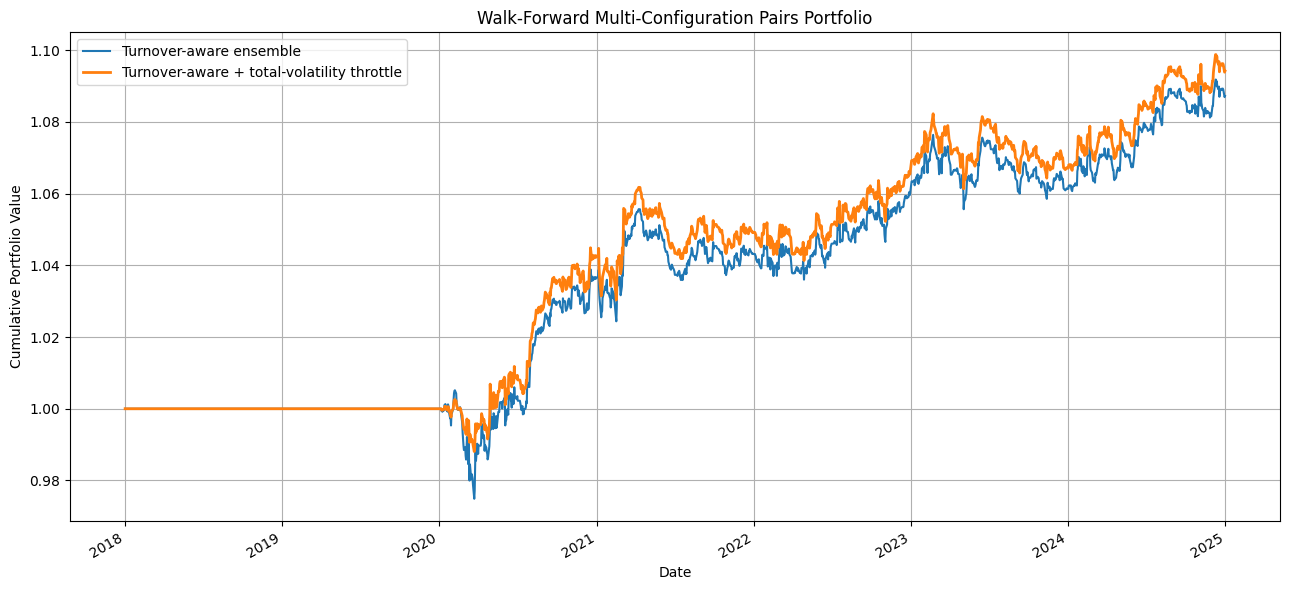

In [ ]:
# ============================================================
# CUMULATIVE PERFORMANCE
# ============================================================

plt.figure(
    figsize=(13, 6)
)

(
    1 + turnover_aware_returns
).cumprod().plot(
    label="Turnover-aware ensemble",
    linewidth=1.5
)

(
    1 + final_portfolio_returns
).cumprod().plot(
    label="Turnover-aware + total-volatility throttle",
    linewidth=2
)

plt.title(
    "Walk-Forward Multi-Configuration Pairs Portfolio"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

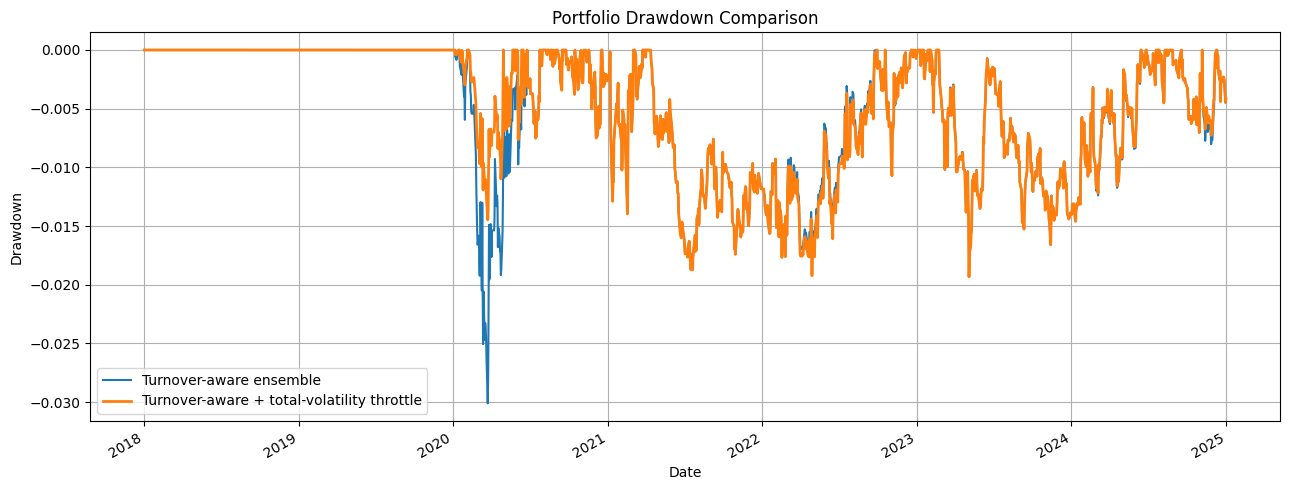

In [ ]:
# ============================================================
# DRAWDOWN
# ============================================================

plt.figure(
    figsize=(13, 5)
)

calculate_drawdown(
    turnover_aware_returns
).plot(
    label="Turnover-aware ensemble",
    linewidth=1.5
)

calculate_drawdown(
    final_portfolio_returns
).plot(
    label="Turnover-aware + total-volatility throttle",
    linewidth=2
)

plt.title(
    "Portfolio Drawdown Comparison"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

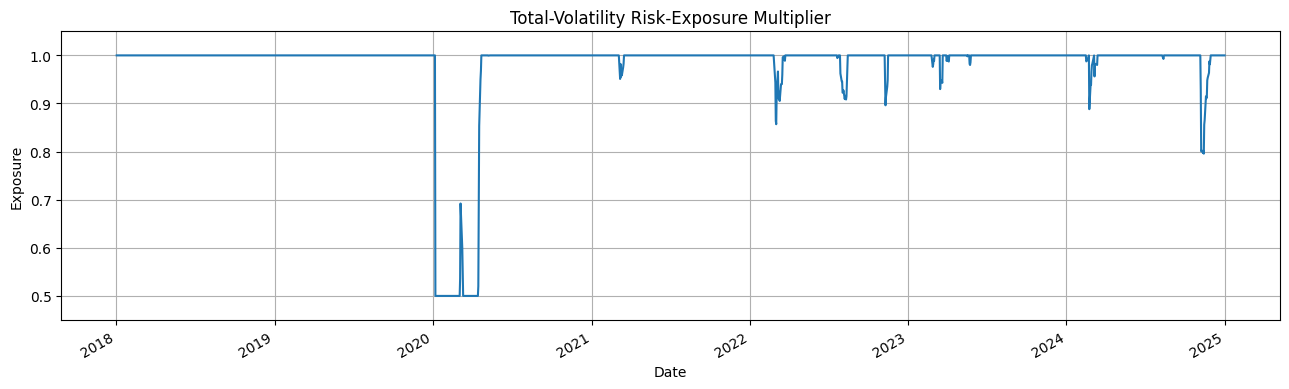

In [ ]:
# ============================================================
# THROTTLE EXPOSURE
# ============================================================

plt.figure(
    figsize=(13, 4)
)

throttle_exposure.plot(
    linewidth=1.5
)

plt.title(
    "Total-Volatility Risk-Exposure Multiplier"
)

plt.xlabel("Date")
plt.ylabel("Exposure")
plt.ylim(
    THROTTLE_MIN_EXPOSURE - 0.05,
    1.05
)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ROLLING ONE-YEAR SHARPE
# ============================================================

def rolling_sharpe(
    returns,
    window=252
):
    returns = (
        pd.Series(returns)
        .fillna(0)
    )

    rolling_mean = (
        returns
        .rolling(
            window,
            min_periods=126
        )
        .mean()
    )

    rolling_volatility = (
        returns
        .rolling(
            window,
            min_periods=126
        )
        .std()
    )

    return (
        rolling_mean
        / rolling_volatility.replace(
            0,
            np.nan
        )
        * np.sqrt(TRADING_DAYS)
    )

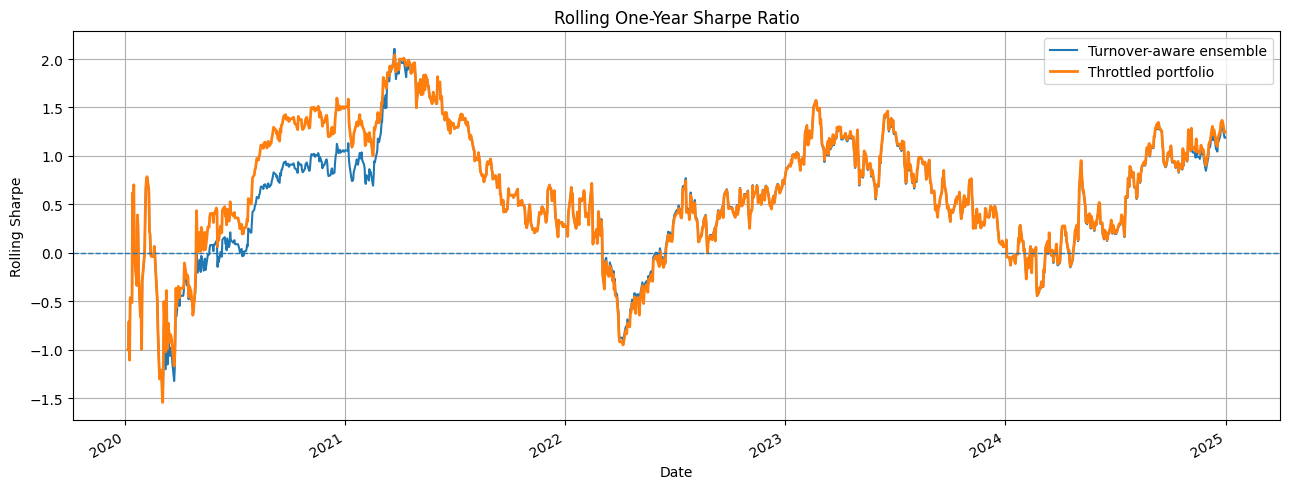

In [653]:
plt.figure(
    figsize=(13, 5)
)

rolling_sharpe(
    turnover_aware_returns
).plot(
    label="Turnover-aware ensemble"
)

rolling_sharpe(
    final_portfolio_returns
).plot(
    label="Throttled portfolio",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Rolling One-Year Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Results and Interpretation

The final turnover-aware ensemble produced a Sharpe ratio of approximately 0.68. Applying the total-volatility throttle increased the Sharpe ratio to approximately 0.79, while reducing maximum drawdown from about 3.0% to 1.9%.

The risk overlay improved both return and volatility characteristics despite never increasing exposure above the unthrottled strategy. This suggests that unusually volatile periods were less favorable for the portfolio and that temporarily reducing risk improved the consistency of returns.

The active-day win rate remained below 50%, but the strategy was profitable because the average payoff of winning periods outweighed that of losing periods. The high active-day ratio reflects diversification across several pairs and signal configurations: although individual positions frequently open and close, at least part of the portfolio is usually invested.

The relatively low annualized volatility and drawdown indicate that the model produced a defensive return stream. Its principal result is therefore the level of risk-adjusted performance rather than a high absolute return.

Performance charts, drawdown curves, exposure plots, and rolling Sharpe ratios are used to assess whether profitability was persistent or concentrated in a small number of periods. The results show meaningful variation through time, reinforcing the importance of rolling validation and portfolio-level risk control.

## 10. Conclusion

The final strategy combines sector-based candidate screening, cointegration and stationarity testing, spread half-life estimation, multiple mean-reversion configurations, sequential validation folds, turnover-aware ensemble weights, maximum-weight graph matching, diversified pair weights, transaction costs, quarterly retraining, and a volatility-based portfolio throttle.

The best development-period model achieved a Sharpe ratio of approximately 0.79 with a maximum drawdown of approximately 1.9%. The strongest improvement came from combining stable signal configurations and controlling portfolio exposure during unusually volatile periods rather than from relying on one highly optimized trading rule.

The result should nevertheless be interpreted cautiously. During development, many alternatives were examined, including simpler cointegration models, distance-based pairs, momentum and mean-reversion switching, PCA and clustering, covariance-based allocation, consensus signals, market-beta adjustments, downside-risk weights, graph-selection variants, drawdown controls, and several volatility overlays.

Because these models were repeatedly modified after examining performance on the same historical period, the final result is affected by data snooping and model-selection bias. The walk-forward structure limits direct look-ahead within each backtest, but it does not make the selected 0.79 Sharpe a completely independent out-of-sample result. Its generalizability should therefore be treated less seriously than a result from a model specified in advance and evaluated once on untouched data.